# Analisi Diffusione COVID-19
## Obiettivo del progetto

Il presente report analizza i dati relativi alla pandemia COVID-19, con un focus su alcuni paesi Europei, utilizzando il dataset curato da **Our World in Data**.

L'analisi si propone di fornire insights significativi su:

- **Distribuzione geografica** dei casi COVID-19 per continente
- **Evoluzione temporale** della pandemia in specifiche nazioni europee
- **Impatto sanitario** attraverso l'analisi delle terapie intensive e ospedalizzazioni 
- **Confronti internazionali** tra Italia, Germania, Francia e Spagna

***
## Struttura del Report

Il documento è organizzato nelle seguenti sezioni principali:

- **Sezione 1**: Exploratory Data Analysis (EDA) - Comprensione della struttura dati
- **Sezione 2**: Analisi per Continenti (casi totali, percentuali, evoluzione)
- **Sezione 3**: Focus Italia 2022 (analisi dettagliata dei dati nazionali)
- **Sezione 4**: Confronto Internazionale (terapie intensive in Italia, Germania e Francia)
- **Sezione 5**: Analisi 2021 in Italia, Germania, Francia e Spagna (ospedalizzazioni e gestione dati mancanti)

***

### Sezione 1: Exploratory Data Analysis (EDA) - Comprensione della struttura dati

In [138]:
#Importo librerie e carico il csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('owid-covid-data.csv')

In [2]:
df #anteprima del dataset

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN


In [3]:
df.info() #info generale del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [124]:
df.describe() #descrittori statistici delle colonne numeriche

,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,429435,4.118040e+05,4.101590e+05,4.089290e+05,4.118040e+05,410608.000000,409378.000000,411804.000000,410159.000000,408929.000000,...,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
mean,2022-04-21 01:06:25.463691008,7.365292e+06,8.017360e+03,8.041026e+03,8.125957e+04,71.852139,72.060873,112096.199396,122.357074,122.713844,...,33.097723,50.649264,3.106912,73.702098,0.722139,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666400
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.188000,0.100000,53.280000,0.394000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.453100
25%,2021-03-05 00:00:00,6.280750e+03,0.000000e+00,0.000000e+00,4.300000e+01,0.000000,0.000000,1916.100500,0.000000,0.000000,...,22.600000,20.859000,1.300000,69.500000,0.602000,5.237980e+05,1.765000e+02,2.060000,-1.500000,116.872242
50%,2022-04-20 00:00:00,6.365300e+04,0.000000e+00,1.200000e+01,7.990000e+02,0.000000,0.000000,29145.475000,0.000000,2.794000,...,33.100000,49.542000,2.500000,75.050000,0.740000,6.336393e+06,6.815199e+03,8.130000,5.660000,1270.801400
75%,2023-06-08 00:00:00,7.582720e+05,0.000000e+00,3.132860e+02,9.574000e+03,0.000000,3.143000,156770.190000,0.000000,56.253000,...,41.500000,82.502000,4.210000,79.460000,0.829000,3.296952e+07,3.912804e+04,15.160000,15.575000,2883.024150
max,2024-08-14 00:00:00,7.758668e+08,4.423623e+07,6.319461e+06,7.057132e+06,103719.000000,14817.000000,763598.600000,241758.230000,34536.890000,...,78.100000,100.000000,13.800000,86.750000,0.957000,7.975105e+09,1.349776e+06,78.080000,378.220000,10293.515000
std,NaN,4.477582e+07,2.296649e+05,8.661611e+04,4.411901e+05,1368.322990,513.636567,162240.412419,1508.778583,559.701638,...,13.853948,31.905375,2.549205,7.387914,0.148903,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892769


In [112]:
sorted(df.columns) #panoramica sulle colonne

['aged_65_older',
 'aged_70_older',
 'cardiovasc_death_rate',
 'continent',
 'date',
 'diabetes_prevalence',
 'excess_mortality',
 'excess_mortality_cumulative',
 'excess_mortality_cumulative_absolute',
 'excess_mortality_cumulative_per_million',
 'extreme_poverty',
 'female_smokers',
 'gdp_per_capita',
 'handwashing_facilities',
 'hosp_patients',
 'hosp_patients_per_million',
 'hospital_beds_per_thousand',
 'human_development_index',
 'icu_patients',
 'icu_patients_per_million',
 'iso_code',
 'life_expectancy',
 'location',
 'male_smokers',
 'median_age',
 'new_cases',
 'new_cases_per_million',
 'new_cases_smoothed',
 'new_cases_smoothed_per_million',
 'new_deaths',
 'new_deaths_per_million',
 'new_deaths_smoothed',
 'new_deaths_smoothed_per_million',
 'new_people_vaccinated_smoothed',
 'new_people_vaccinated_smoothed_per_hundred',
 'new_tests',
 'new_tests_per_thousand',
 'new_tests_smoothed',
 'new_tests_smoothed_per_thousand',
 'new_vaccinations',
 'new_vaccinations_smoothed',
 'ne

In [6]:
print("Righe duplicate:", df.duplicated().sum()) #controllo se ci sono righe duplicate nel df

Righe duplicate: 0


In [7]:
#credo un ciclo for per avere un conteggio di NaN per colonna
print('-- CONTEGGIO VALORI NULLI PER COLONNA --')
for column in df.columns:
    nan_count = df[column].isnull().sum()
    if nan_count > 0:
        print(f'{column}: {nan_count:,}')

-- CONTEGGIO VALORI NULLI PER COLONNA --
continent: 26,525
total_cases: 17,631
new_cases: 19,276
new_cases_smoothed: 20,506
total_deaths: 17,631
new_deaths: 18,827
new_deaths_smoothed: 20,057
total_cases_per_million: 17,631
new_cases_per_million: 19,276
new_cases_smoothed_per_million: 20,506
total_deaths_per_million: 17,631
new_deaths_per_million: 18,827
new_deaths_smoothed_per_million: 20,057
reproduction_rate: 244,618
icu_patients: 390,319
icu_patients_per_million: 390,319
hosp_patients: 388,779
hosp_patients_per_million: 388,779
weekly_icu_admissions: 418,442
weekly_icu_admissions_per_million: 418,442
weekly_hosp_admissions: 404,938
weekly_hosp_admissions_per_million: 404,938
total_tests: 350,048
new_tests: 354,032
total_tests_per_thousand: 350,048
new_tests_per_thousand: 354,032
new_tests_smoothed: 325,470
new_tests_smoothed_per_thousand: 325,470
positive_rate: 333,508
tests_per_case: 335,087
tests_units: 322,647
total_vaccinations: 344,018
people_vaccinated: 348,303
people_fully_v

In [119]:
print(f'-- VALORI UNICI COLONNE PRINCIPALI --')
#verifico quante entità uniche ci sono per capire se ci sono duplicati o anomalie
print('Location unique:', df['location'].nunique())
print('Continent unique:', df['continent'].nunique()) 
print('ISO code unique:', df['iso_code'].nunique())
print('ICU patients unique:', df['icu_patients'].nunique())
print('HOSP patients code unique:', df['hosp_patients'].nunique())
print('New cases unique:', df['new_cases'].nunique())
print('Total cases unique:', df['total_cases'].nunique())
print('Date unique:', df['date'].nunique())

-- VALORI UNICI COLONNE PRINCIPALI --
Location unique: 255
Continent unique: 6
ISO code unique: 255
ICU patients unique: 4133
HOSP patients code unique: 10551
New cases unique: 14158
Total cases unique: 36694
Date unique: 1688


In [140]:
print(f'-- RANGE TEMPORALE --')
print("Prima data:", df['date'].min())
print("Ultima data:", df['date'].max())
print("Tipo dato date:", df['date'].dtype)

#trasformo tipo di dato object in date
df['date'] = pd.to_datetime(df['date']) 

-- RANGE TEMPORALE --
Prima data: 2020-01-01 00:00:00
Ultima data: 2024-08-14 00:00:00
Tipo dato date: datetime64[ns]


In [121]:
#controllo se ci sono i paesi target per la mia analisi (Italia, Germania, Spagna, Francia)
print(f'-- PAESI TARGET --')
country_target = ['Italy', 'Germany', 'Spain', 'France']
for country in country_target:
    if country in df['location'].values:
        print(f'{country} è presente')
    else:
        print(f'{country} non è presente')

-- PAESI TARGET --
Italy è presente
Germany è presente
Spain è presente
France è presente


In [142]:
#creo una variabile dove ho valori NaN nella colonna 'continent'
continent_null = df[df['continent'].isnull()] 

#creo una variabile dei valori da non conteggiare nelle future analisi
location_to_exclude = continent_null['location'].unique() 

print(f'Location da escludere: {len(location_to_exclude)} \n{location_to_exclude}')

#versione del dataset senza valori aggregati della colonna 'location'
df_clean = df[~df['location'].isin(location_to_exclude)].copy() 

print(f'\nDataset originale: {len(df)} righe')   
print(f'Dataset pulito: {len(df_clean)} righe')
print(f'Location con aggregati: {df['location'].nunique()}')
print(f'Location senza aggregati: {df_clean['location'].nunique()}')

Location da escludere: 12 
['Africa' 'Asia' 'Europe' 'European Union (27)' 'High-income countries'
 'Low-income countries' 'Lower-middle-income countries' 'North America'
 'Oceania' 'South America' 'Upper-middle-income countries' 'World']

Dataset originale: 429435 righe
Dataset pulito: 402910 righe
Location con aggregati: 255
Location senza aggregati: 243


In [15]:
df_clean[['date', 'continent', 'location', 'total_cases']] 

,date,continent,location,total_cases
0,2020-01-05,Asia,Afghanistan,0.0
1,2020-01-06,Asia,Afghanistan,0.0
2,2020-01-07,Asia,Afghanistan,0.0
3,2020-01-08,Asia,Afghanistan,0.0
4,2020-01-09,Asia,Afghanistan,0.0
...,...,...,...,...
429430,2024-07-31,Africa,Zimbabwe,266386.0
429431,2024-08-01,Africa,Zimbabwe,266386.0
429432,2024-08-02,Africa,Zimbabwe,266386.0
429433,2024-08-03,Africa,Zimbabwe,266386.0


***

### Sezione 2: Analisi per Continenti (casi totali, percentuali, evoluzione) 


In [137]:
#totale casi raggruppato per paese e continenti
location_totals = df_clean.groupby(['continent', 'location'])['total_cases'].max() 

#raggruppo ulteriormente e sommo i casi per ottenere il totale per continenti
continent_totals = location_totals.groupby('continent').sum()

print(f'TOTALE CASI PER CONTINENTE: \n{continent_totals.map('{:,.0f}'.format)}')

#calcolo il totale dei casi mondiale 
total = continent_totals.sum() 

#calcolo la percentuale dei casi per continente rispetto al totale modiale 
percentage = (continent_totals/total)*100 

print(f'\nTOTALE MONDIALE CASI: {total:,}')
print(f'\nPERCENTUALI PER CONTINENTE RISPETTO AL TOTALE MONDIALE:')
print(percentage.map('{:.2f}%'.format))

TOTALE CASI PER CONTINENTE: 
continent
Africa            13,145,540
Asia             301,532,347
Europe           252,916,868
North America    124,492,666
Oceania           15,003,352
South America     68,809,418
Name: total_cases, dtype: object

TOTALE MONDIALE CASI: 775,900,191.0

PERCENTUALI PER CONTINENTE RISPETTO AL TOTALE MONDIALE:
continent
Africa            1.69%
Asia             38.86%
Europe           32.60%
North America    16.04%
Oceania           1.93%
South America     8.87%
Name: total_cases, dtype: object


***

### Sezione 3: Focus Italia 2022 (analisi dettagliata dei dati nazionali)


<Axes: title={'center': 'Andamento Nuovi Casi COVID-19 ITALIA 2022'}, xlabel='date'>

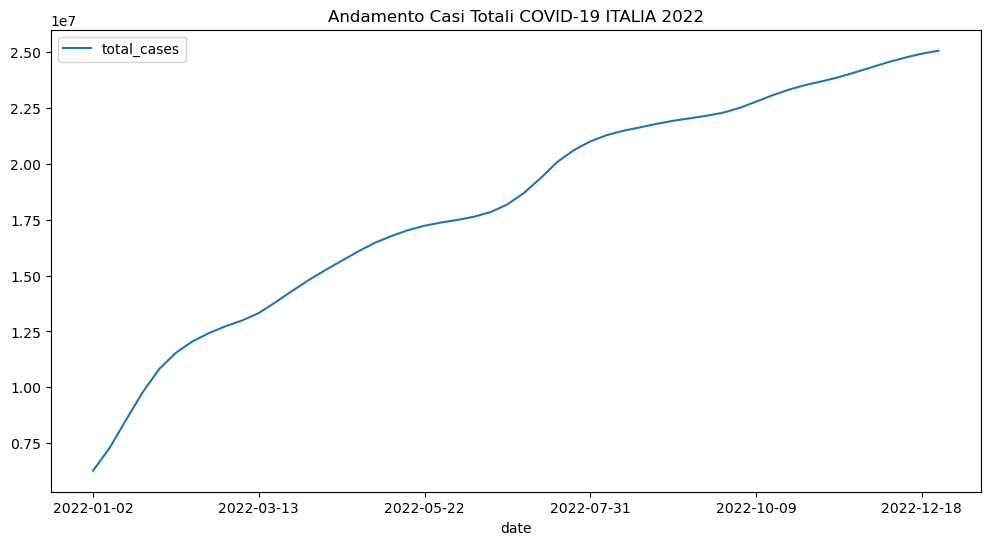

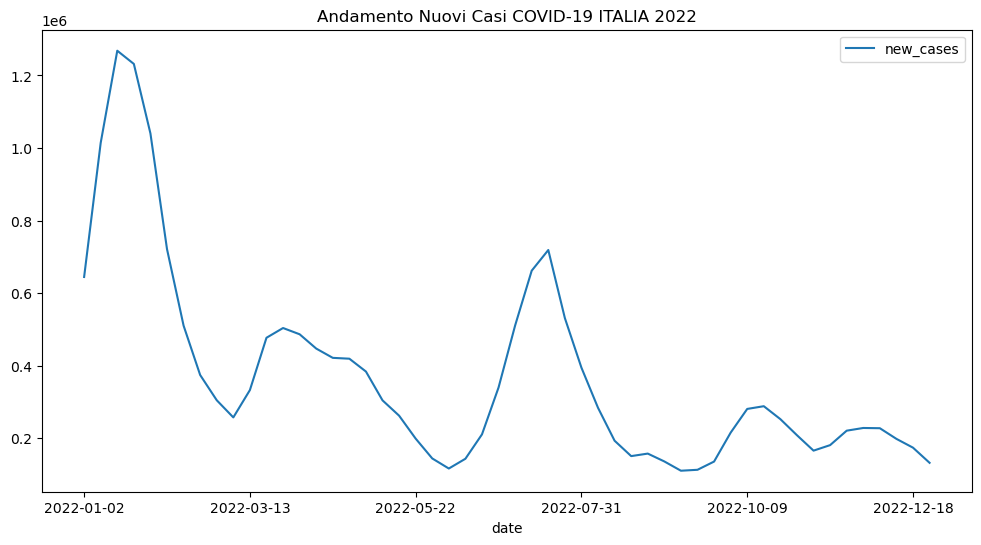

In [57]:
#Creo una variabile per l'anno 2022
year_2022 = df_clean[
    (df_clean['date'] >= "2022-01-01") & 
    (df_clean['date'] <= "2022-12-31")
] 

#Creo una variabile per Italia anno 2022
italy_2022 = year_2022[year_2022['location'] == 'Italy'] 

#filtro via i giorni che non hanno misurazioni essendo una misurazione settimanale 
date_filter = italy_2022[italy_2022['new_cases'] > 0] 

#grafico evoluzione casi totali anno 2022
date_filter.plot(x='date', y='total_cases', 
                 title= 'Andamento Casi Totali COVID-19 ITALIA 2022',
                 figsize= (12, 6))

#grafico andamento nuovi casi 
date_filter.plot(x= 'date', y= 'new_cases',
                title= 'Andamento Nuovi Casi COVID-19 ITALIA 2022',
                figsize= (12, 6))

Il **primo grafico** mette in evidenza la crescita dei casi totali in **Italia** nel **2022**. Mentre il **secondo grafico** presenta l'andamento dei nuovi casi giornalieri registrati. Questa metrica evidenzia la dinamica dell'epidemia e i picchi di contagio in specifiche date. 

***

### Sezione 4: Confronto Internazionale (terapie intensive in Italia, Germania e Francia)


Valori nulli icu_patients: 
30

Conteggio valori non NaN: 
location
France     335
Germany    365
Italy      365
Name: icu_patients, dtype: int64

Totale ICU per paese da Maggio 2022 ad Aprile 2023: 
location
France     334457.0
Germany    373171.0
Italy       84408.0
Name: icu_patients, dtype: float64


Text(0.5, 1.0, 'PAZIENTI IN TERAPIA INTENSIVA MAGGIO 2022 - APRILE 2023')

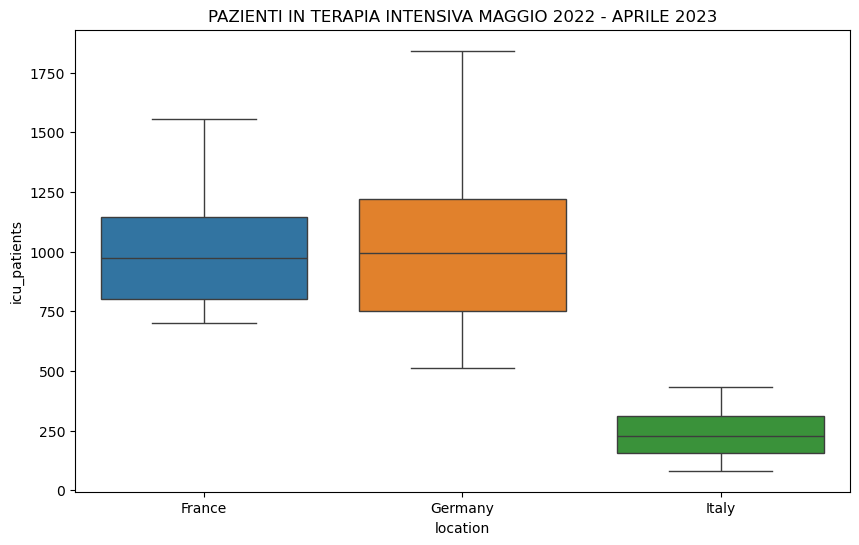

In [113]:
#filtro nazioni Italy, Germany, France
location_filter = df_clean[
    (df_clean['location'] == 'Italy') | 
    (df_clean['location'] == 'Germany') | 
    (df_clean['location'] == 'France')
] 

#filtro periodo Maggio 2022 - Aprile 2023
icu_analysis_filter = location_filter[
    (location_filter['date'] >= '2022-05-01') &
    (location_filter['date'] <= '2023-04-30')
] 

#verifico che ci siano dati ICU e quanti valori sono nulli
print(f'Valori nulli icu_patients: \n{icu_analysis_filter['icu_patients'].isnull().sum()}')

print(f'\nConteggio valori non NaN: \n{icu_analysis_filter.groupby('location')['icu_patients'].count()}')

print(f'\nTotale ICU per paese da Maggio 2022 ad Aprile 2023: \n{icu_analysis_filter.groupby('location')['icu_patients'].sum()}')

#procedo con il grafico
plt.figure(figsize=(10, 6))
sns.boxplot(data= icu_analysis_filter, 
            x= 'location', 
            y= 'icu_patients',
            hue= 'location')
plt.title('PAZIENTI IN TERAPIA INTENSIVA MAGGIO 2022 - APRILE 2023')


L'analisi mostra differenze significative nei pazienti ICU: l'**Italia** presenta valori inferiori (**mediana \~250**), mentre **Germania** e **Francia** operano su livelli simili (**\~950-1000**) ma con oscillazioni più ampie, suggerendo diversi approcci nella gestione della pressione ospedaliera COVID.

(Si noti che per la Francia mancano 30 giorni di dati ICU nel periodo analizzato).

***


### Sezione 5: Analisi 2021 in Italia, Germania, Francia e Spagna (ospedalizzazioni e gestione dati mancanti)


Totale pazienti ospedalizzati per COVID-19 nel 2021:
location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64


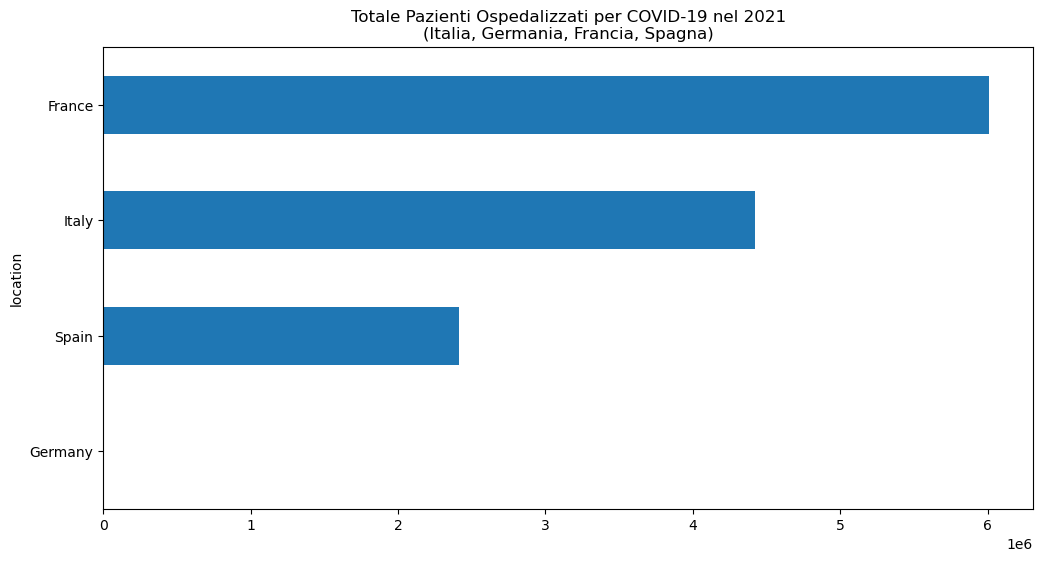

In [116]:
#filtro per le nazioni: Italia, Germania, Francia e Spagna
location_filter2 = df_clean[
    (df_clean['location'] == 'Italy') |
    (df_clean['location'] == 'Germany') |
    (df_clean['location'] == 'France') |
    (df_clean['location'] == 'Spain')
]

#filtro anno 2021
date_filter2 = location_filter2[
    (location_filter2['date'] >= '2021-01-01') &
    (location_filter2['date'] <= '2021-12-31')
]

#calcolo totali HOSP per nazioni
total_hosp = date_filter2.groupby('location')['hosp_patients'].sum()

#creazione grafico
plt.figure(figsize= (12, 6))
total_hosp.sort_values().plot(kind='barh')
plt.title('Totale Pazienti Ospedalizzati per COVID-19 nel 2021\n(Italia, Germania, Francia, Spagna)')
          
print(f'Totale pazienti ospedalizzati per COVID-19 nel 2021:\n{date_filter2.groupby('location')['hosp_patients'].sum()}')



La **Germania** presenta tutti valori **nulli** per hosp_patients nel 2021, rendendo impossibile qualsiasi sostituzione sensata.

***

## Conclusioni Generali

L'analisi del dataset COVID-19 di **Our World in Data** ha fornito una panoramica sull'impatto pandemico a livello globale e nazionale, con focus sulle nazioni Europee. I dati evidenziano **disparità geografiche** nella **distribuzione dei casi**, **ospedalizzazioni** e **terapie intensive**, confermando l'efficacia in alcuni casi delle strategie di monitoraggio adottate nel corso dell'evoluzione pandemica.